In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# external imports
from pathlib import Path
import os
from dotenv import load_dotenv
from torch_geometric.data import Batch
import torch
import random

In [3]:
# internal imports
from primaite.network.generator import NetworkGenerator
from primaite.agents.aegis.modules.openai import OpenAIClient

2024-09-26 10:37:04.673519: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-26 10:37:04.705513: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-26 10:37:05.267394: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/sam/projects/PrimAITE/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sam/projects/PrimAITE/.venv/lib/python3.10/site-packages/pydantic/_internal/_fields.py:161: UserWarning: Field "model_id" has conflict with protected name

In [4]:
# constants
NUMBER_OF_NODES = 40
RANDOM_SEED = 1729
TRAINING_CONFIG_PATH = Path("../agents") / "training_configs" / "do_nothing.yaml"
SERVICE_NAMES = ["HTTP", "SSH", "FTP"]
PORTS_LIST = ["80", "22", "21"]
DATASET_SAVE_PATH = Path("../data") / "generated_data" / "data.pt"
DATASET_SIZE = 1

In [5]:
generator = NetworkGenerator(
    graph_size=NUMBER_OF_NODES, 
    training_config_path=TRAINING_CONFIG_PATH, 
    random_seed=1729, 
    services=SERVICE_NAMES, 
    ports=PORTS_LIST
)

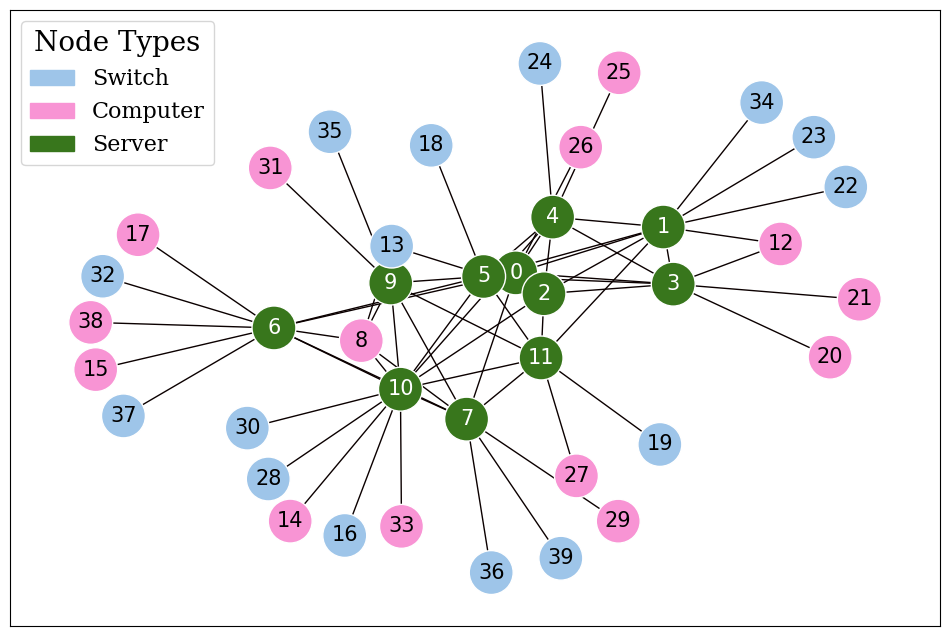

In [17]:
from matplotlib.colors import Normalize
import networkx as nx
import matplotlib.pyplot as plt
from primaite.common.enums import NodeType

import matplotlib.patches as mpatches

plt.rcParams["font.family"] = "serif"


colours = {
    "green": "#38761C",
    "light-blue": "#9EC5E9",
    "dark-blue": "#1055cc",
    "red": "#FF0000",
    "pink": "#F894D4"
}

# Create a list of legend handles based on NODE_TYPE_MAP
legend_patches = [
    mpatches.Patch(color=colours["light-blue"], label="Switch"),
    mpatches.Patch(color=colours["pink"], label="Computer"),
    mpatches.Patch(color=colours["green"], label="Server"),
]


NODE_TYPE_MAP = {
    NodeType.SWITCH: {"colour": colours["light-blue"]},   
    NodeType.COMPUTER: {"colour": colours["pink"]}, 
    NodeType.SERVER: {"colour": colours["green"]},   
}

pos = nx.spring_layout(generator.graph, seed=generator.random_seed)

node_colors = [NODE_TYPE_MAP[v['type']]["colour"] for _, v in generator.graph.nodes(data=True)]

# get traffic on each edge
edge_traffic_levels = []
for index, _ in enumerate(generator.graph.edges(data=True)):
    link_id = f"{index}"
    link = generator.links_dict[link_id]
    traffic_level = link.get_traffic_level()
    edge_traffic_levels.append(traffic_level)

# normalize edge traffic levels for better visualization
norm = Normalize(vmin=min(edge_traffic_levels), vmax=max(edge_traffic_levels))
edge_colors_normalized = [norm(level) for level in edge_traffic_levels]

# Create a new figure
fig, ax = plt.subplots(figsize=(12, 8))

# draw the network with edges colored by traffic level
nx.draw_networkx(
    generator.graph,
    pos=pos,
    node_color=node_colors,
    node_size=1000,
    edgecolors='white', 
    with_labels=False,
    edge_color=edge_colors_normalized,
    edge_cmap=plt.cm.hot, 
    edge_vmax=1.0,
    ax=ax
)

# Extract node positions for green nodes and others
green_nodes = {node: pos[node] for node, data in generator.graph.nodes(data=True) if NODE_TYPE_MAP[data['type']]['colour'] == colours['green']}
other_nodes = {node: pos[node] for node in generator.graph.nodes() if node not in green_nodes}

font_size = 15

# Draw labels with white text for green nodes
nx.draw_networkx_labels(generator.graph, pos=green_nodes, labels={node: node for node in green_nodes},
                        font_size=font_size, font_color="white", ax=ax, font_family="serif")

# Draw labels with black text for other nodes
nx.draw_networkx_labels(generator.graph, pos=other_nodes, labels={node: node for node in other_nodes},
                        font_size=font_size, font_color="black", ax=ax)

edge_labels = {(u, v): index for index, (u, v, _) in enumerate(generator.graph.edges(data=True))}
ax.legend(handles=legend_patches, loc="upper left", title="Node Types", fontsize=16, title_fontsize=20)

fig.savefig("../network_image.pdf", bbox_inches='tight')

In [7]:
generator.nodes_dict['0'].serialize()

{'item_type': 'NODE',
 'node_id': '0',
 'name': 'SERVER_1',
 'node_class': 'SERVICE',
 'node_type': 'SERVER',
 'priority': 'P5',
 'hardware_state': 'ON',
 'ip_address': '192.168.1.1',
 'software_state': 'PATCHING',
 'file_system_state': 'REPAIRING',
 'services': [{'name': 'SSH', 'port': '22', 'state': 'GOOD'},
  {'name': 'FTP', 'port': '21', 'state': 'GOOD'}]}

In [8]:
for node_id in list(generator.nodes_dict.keys()):
    
    node = generator.nodes_dict['0'].serialize()


In [9]:
SELECTED_NODES_IDS = ["1", "3", "12", "22", "23", "34"]

In [10]:
import pandas as pd  

# Initialize an empty DataFrame
df = pd.DataFrame(columns=['Name', 'Hardware', 'Software', 'File System', 'SSH', 'FTP', 'HTTP'])

# Extract information for the first 5 nodes (or all if there are fewer)
for node_id in list(generator.nodes_dict.keys()):

    if node_id in SELECTED_NODES_IDS:


        node_info = generator.nodes_dict[node_id].serialize() 
        
        print(node_info)

        row = {}
        row["Id"] = node_id
        row["Name"] = node_info["name"]
        row["Software"] = node_info["software_state"]
        row["Hardware"] = node_info["hardware_state"]
        row["File System"] = node_info["file_system_state"]

        # add services
        if "services" in node_info:
            for service in node_info["services"]:
                row[service["name"]] = service["state"]

        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    
df.fillna("-", inplace=True)

df

{'item_type': 'NODE', 'node_id': '1', 'name': 'SERVER_2', 'node_class': 'SERVICE', 'node_type': 'SERVER', 'priority': 'P2', 'hardware_state': 'RESETTING', 'ip_address': '192.168.1.1', 'software_state': 'NONE', 'file_system_state': 'GOOD', 'services': [{'name': 'SSH', 'port': '22', 'state': 'OVERWHELMED'}, {'name': 'FTP', 'port': '21', 'state': 'OVERWHELMED'}, {'name': 'HTTP', 'port': '80', 'state': 'OVERWHELMED'}]}
{'item_type': 'NODE', 'node_id': '3', 'name': 'SERVER_4', 'node_class': 'SERVICE', 'node_type': 'SERVER', 'priority': 'P3', 'hardware_state': 'ON', 'ip_address': '192.168.1.1', 'software_state': 'GOOD', 'file_system_state': 'RESTORING', 'services': [{'name': 'SSH', 'port': '22', 'state': 'OVERWHELMED'}]}
{'item_type': 'NODE', 'node_id': '12', 'name': 'COMPUTER_2', 'node_class': 'SERVICE', 'node_type': 'COMPUTER', 'priority': 'P5', 'hardware_state': 'ON', 'ip_address': '192.168.1.1', 'software_state': 'OVERWHELMED', 'file_system_state': 'NONE', 'services': [{'name': 'HTTP', '

,Name,Hardware,Software,File System,SSH,FTP,HTTP,Id
0,SERVER_2,RESETTING,NONE,GOOD,OVERWHELMED,OVERWHELMED,OVERWHELMED,1
1,SERVER_4,ON,GOOD,RESTORING,OVERWHELMED,-,-,3
2,COMPUTER_2,ON,OVERWHELMED,NONE,GOOD,NONE,OVERWHELMED,12
3,SWITCH_5,ON,NONE,REPAIRING,-,-,-,22
4,SWITCH_6,ON,OVERWHELMED,NONE,-,-,-,23
5,SWITCH_11,ON,GOOD,CORRUPT,-,-,-,34


In [11]:
csv_string = df.to_csv(index=False)
print(csv_string)

Name,Hardware,Software,File System,SSH,FTP,HTTP,Id
SERVER_2,RESETTING,NONE,GOOD,OVERWHELMED,OVERWHELMED,OVERWHELMED,1
SERVER_4,ON,GOOD,RESTORING,OVERWHELMED,-,-,3
COMPUTER_2,ON,OVERWHELMED,NONE,GOOD,NONE,OVERWHELMED,12
SWITCH_5,ON,NONE,REPAIRING,-,-,-,22
SWITCH_6,ON,OVERWHELMED,NONE,-,-,-,23
SWITCH_11,ON,GOOD,CORRUPT,-,-,-,34



In [12]:
links = []

# used to create the adj matrix
for link_id in list(generator.links_dict.keys()):
    links.append({ 
        "Link ID": link_id, 
        "Nodes": (generator.links_dict[link_id].source_node_name, generator.links_dict[link_id].dest_node_name) 
    })

print(links)

[{'Link ID': '0', 'Nodes': ('SERVER_1', 'SERVER_2')}, {'Link ID': '1', 'Nodes': ('SERVER_1', 'SERVER_3')}, {'Link ID': '2', 'Nodes': ('SERVER_1', 'SERVER_4')}, {'Link ID': '3', 'Nodes': ('SERVER_1', 'SERVER_5')}, {'Link ID': '4', 'Nodes': ('SERVER_1', 'SERVER_6')}, {'Link ID': '5', 'Nodes': ('SERVER_1', 'SERVER_7')}, {'Link ID': '6', 'Nodes': ('SERVER_1', 'SERVER_8')}, {'Link ID': '7', 'Nodes': ('SERVER_1', 'COMPUTER_9')}, {'Link ID': '8', 'Nodes': ('SERVER_2', 'SERVER_3')}, {'Link ID': '9', 'Nodes': ('SERVER_2', 'SERVER_4')}, {'Link ID': '10', 'Nodes': ('SERVER_2', 'SERVER_5')}, {'Link ID': '11', 'Nodes': ('SERVER_2', 'SERVER_6')}, {'Link ID': '12', 'Nodes': ('SERVER_2', 'SERVER_11')}, {'Link ID': '13', 'Nodes': ('SERVER_2', 'COMPUTER_2')}, {'Link ID': '14', 'Nodes': ('SERVER_2', 'SWITCH_5')}, {'Link ID': '15', 'Nodes': ('SERVER_2', 'SWITCH_6')}, {'Link ID': '16', 'Nodes': ('SERVER_2', 'SWITCH_11')}, {'Link ID': '17', 'Nodes': ('SERVER_3', 'SERVER_4')}, {'Link ID': '18', 'Nodes': ('SE

In [13]:
limit = 5

# Extract unique nodes
nodes = sorted({link["Source Node"] for link in links[:limit]}.union({link["Dest Node"] for link in links[:limit]}))

# Create an empty adjacency matrix
adj_matrix = pd.DataFrame(0, index=nodes, columns=nodes)

# Fill in the adjacency matrix
for link in links:
    source = link["Source Node"]
    dest = link["Dest Node"]
    adj_matrix.at[source, dest] = 1 

KeyError: 'Source Node'

In [ ]:
# Extract all unique nodes from the given data
all_nodes = sorted({node for link in links for node in link['Nodes']})

# Create an empty adjacency matrix initialized with 0
adj_matrix = pd.DataFrame(0, index=all_nodes, columns=all_nodes)

# Populate the adjacency matrix
for link in links:
    source, dest = link['Nodes']
    adj_matrix.at[source, dest] = 1
    adj_matrix.at[dest, source] = 1  # Since it's an undirected graph, mark both [source, dest] and [dest, source]

# Display the adjacency matrix
adj_matrix[
    'SERVER_2'
]

COMPUTER_1     0
COMPUTER_10    1
COMPUTER_11    0
COMPUTER_12    0
COMPUTER_2     0
COMPUTER_3     1
COMPUTER_4     1
COMPUTER_5     0
COMPUTER_6     0
COMPUTER_7     0
COMPUTER_8     0
COMPUTER_9     0
SERVER_1       1
SERVER_10      0
SERVER_11      1
SERVER_2       0
SERVER_3       1
SERVER_4       1
SERVER_5       1
SERVER_6       1
SERVER_7       0
SERVER_8       0
SERVER_9       0
SWITCH_1       1
SWITCH_10      0
SWITCH_11      0
SWITCH_12      0
SWITCH_13      0
SWITCH_14      0
SWITCH_15      0
SWITCH_16      0
SWITCH_17      0
SWITCH_2       0
SWITCH_3       0
SWITCH_4       0
SWITCH_5       0
SWITCH_6       0
SWITCH_7       0
SWITCH_8       0
SWITCH_9       0
Name: SERVER_2, dtype: int64

In [ ]:
adj_matrix

,SERVER_1,SERVER_2,SERVER_3,SERVER_4,SERVER_5,SERVER_6
SERVER_1,0,1,1,1,1,1
SERVER_2,0,0,0,0,0,0
SERVER_3,0,0,0,0,0,0
SERVER_4,0,0,0,0,0,0
SERVER_5,0,0,0,0,0,0
SERVER_6,0,0,0,0,0,0
